In [312]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize']=(12,6)

In [313]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [314]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [315]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [316]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [317]:
df.shape

(891, 12)

In [318]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [319]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [320]:
# As Age Feature has les Missing Values, so we are going to fill it with mean/median as it is continuous numerical 
df['Age']=df['Age'].fillna(df['Age'].median())
df['Age'].head()

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

In [321]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [322]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [323]:
# We are going to drop 'Cabin' cause it has so much null values like 687 from 891
df.drop('Cabin',axis=1,inplace=True)

In [324]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [325]:
# fill the Embarked (Port Location from where passenger boarded the titanic)
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [326]:
# There are only 2 null values it this it is categorical feature fill with mode ( most occuring value) = S
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'].head()

0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: object

In [327]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Univariate Analysis

<Axes: xlabel='Survived', ylabel='count'>

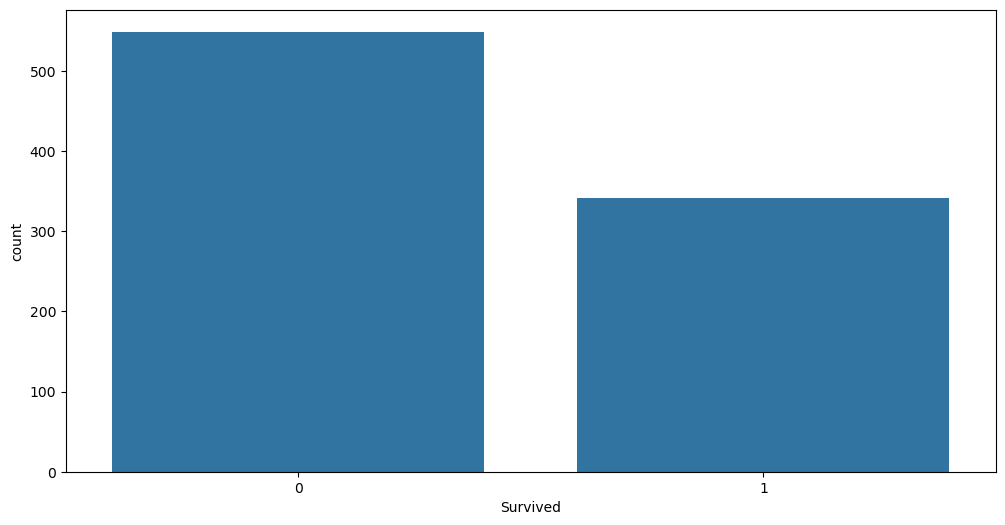

In [328]:
sns.countplot(x='Survived',data=df)

### Obervation : As Plot Shows that Number of the Peoples Survived are Less as Compare to Survived Peoples

<Axes: xlabel='Pclass', ylabel='count'>

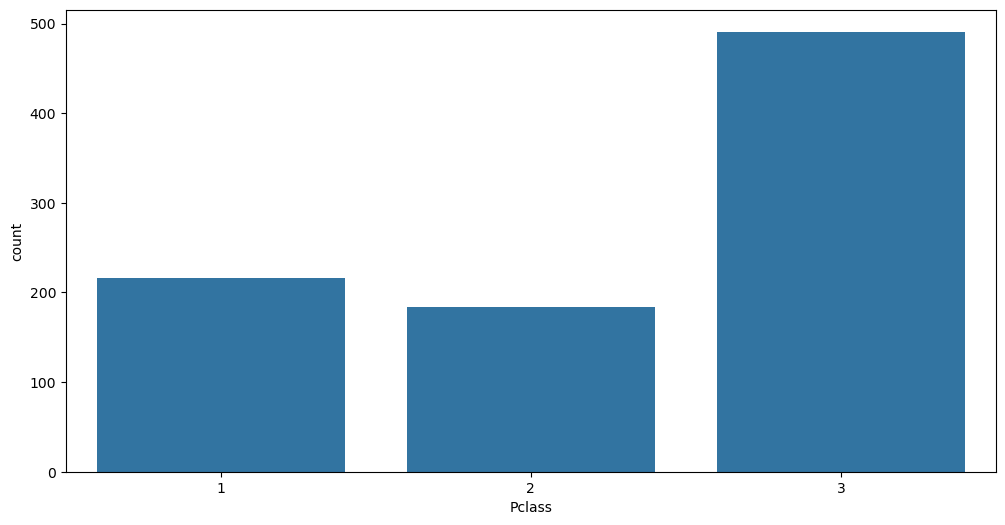

In [329]:
sns.countplot(x='Pclass',data=df)

### Observation : The Number of People from Passenger Class 3 are more and compare to 1 and 2 class

<Axes: xlabel='Sex', ylabel='count'>

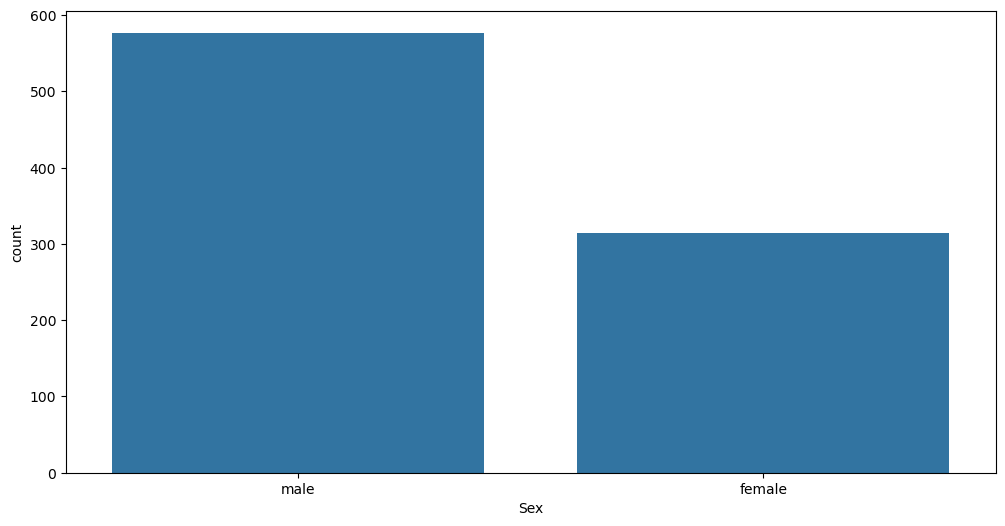

In [330]:
sns.countplot(x='Sex',data=df)

### Observation : The Number of Male is more than the Number of Females

<Axes: xlabel='Age', ylabel='Count'>

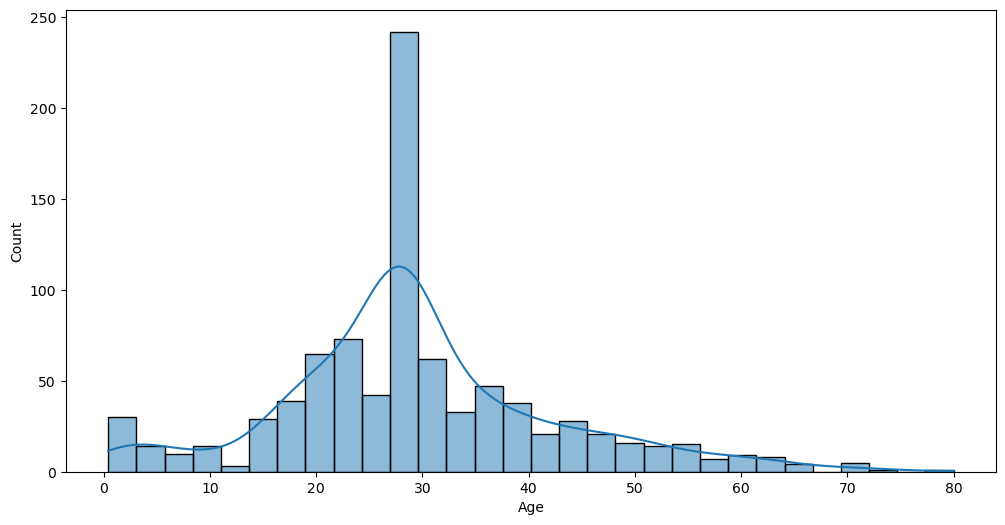

In [331]:
sns.histplot(df['Age'],kde=True)

### observation : The People Aboarded the Titanic of Age Around 30 are more as Compare to other Age Peoples

<Axes: xlabel='SibSp', ylabel='count'>

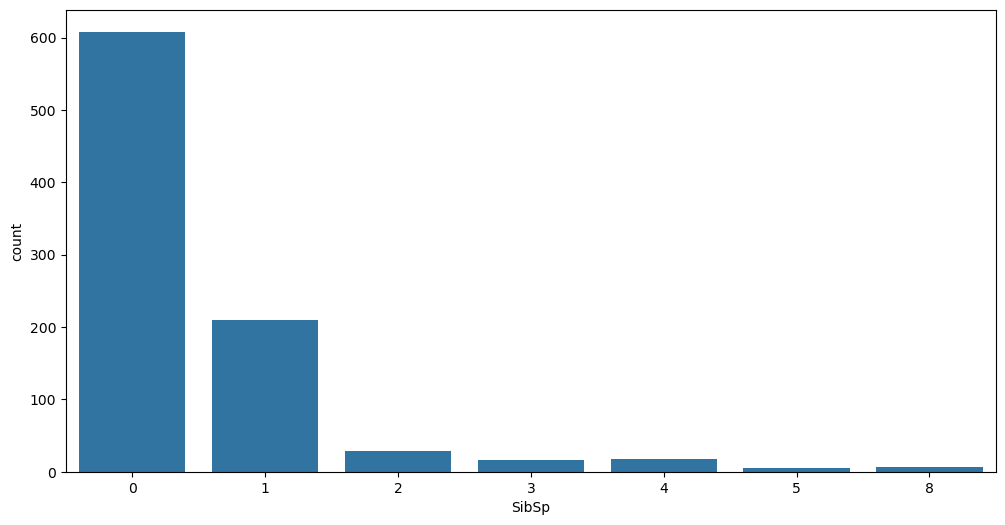

In [332]:
sns.countplot(x='SibSp',data=df)

### Observation : The Number of People Who had Sibling or Spaous aboard Titanic are Less then who had

<Axes: xlabel='Parch', ylabel='count'>

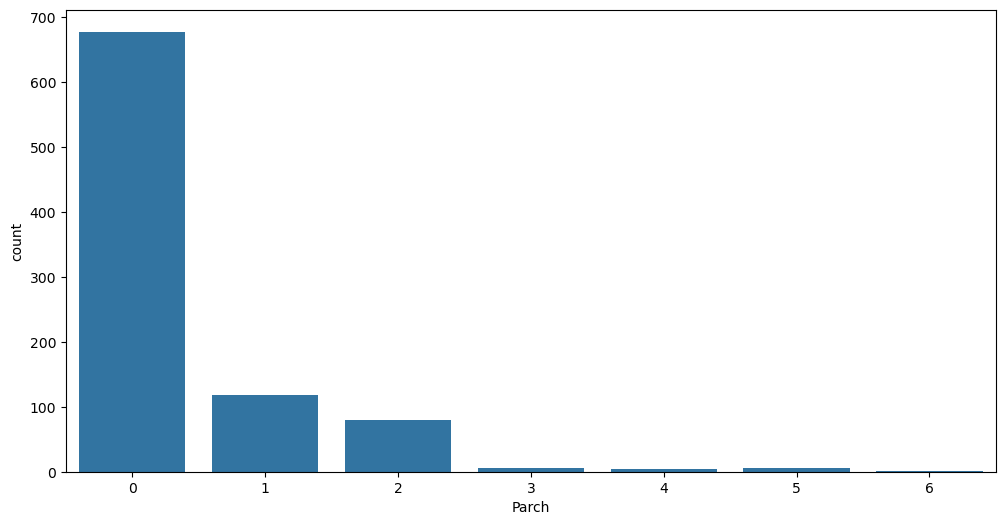

In [333]:
sns.countplot(x='Parch',data=df)

### Observation : The Number of People Who had Parents or Children aboard Titanic are Less then who had¶

<Axes: xlabel='Fare', ylabel='Count'>

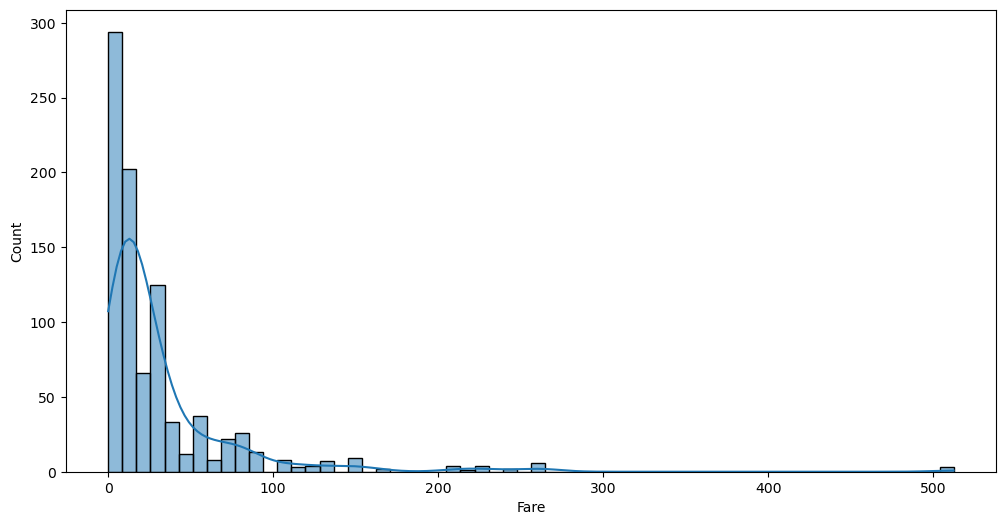

In [334]:
sns.histplot(df['Fare'],kde=True)

### Obsevation : The People had Paid Fare Between 0-100 are More then People who had Paid Fare More than 100-150

<Axes: xlabel='Embarked', ylabel='count'>

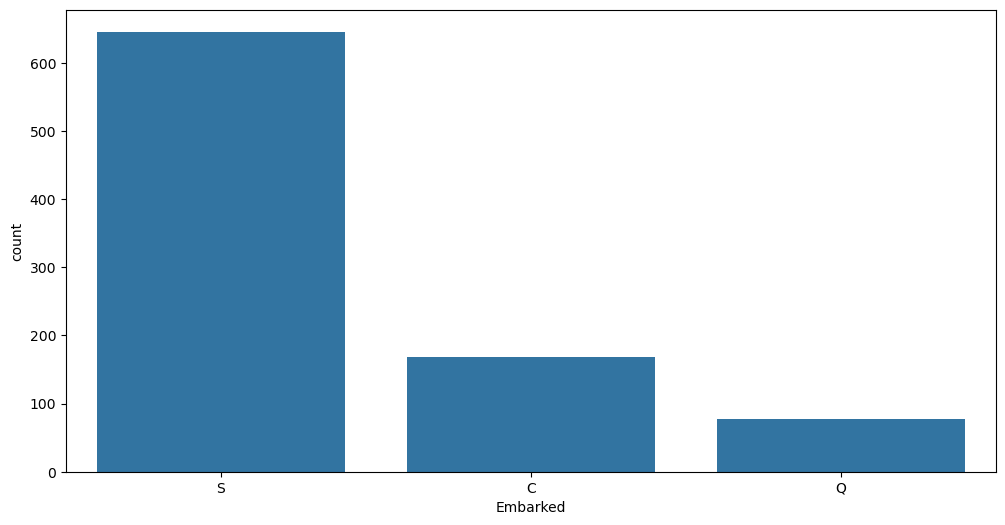

In [335]:
sns.countplot(x='Embarked',data=df)

### Observation : The People Aboared on Titanic from Southampton Area are More than chebourg and Queenstown

## Bivariate Analysis

In [336]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: xlabel='Sex', ylabel='Survived'>

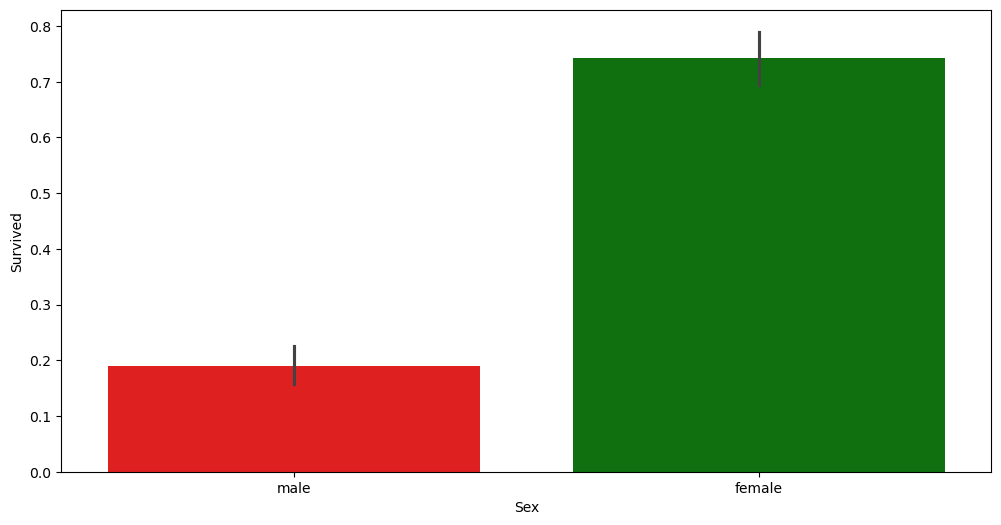

In [337]:
sns.barplot(x='Sex',y='Survived',data=df,hue='Sex',palette=['Red','Green'])

### Observation : The Survival Rate of Female too much higher than the Male 

<Axes: xlabel='Pclass', ylabel='Survived'>

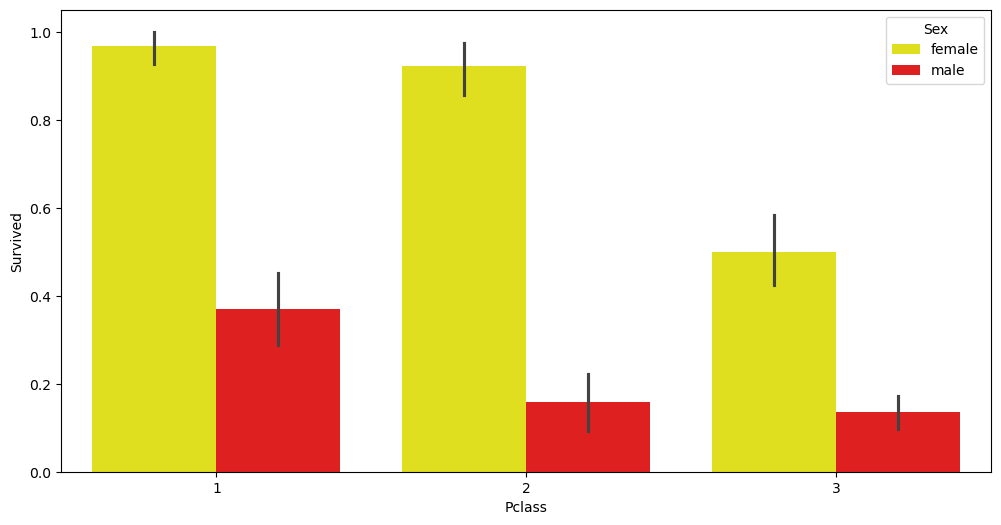

In [338]:
sns.barplot(x='Pclass',y='Survived',data=df,hue='Sex',palette=['Yellow','Red'])

### Observation : The Survival Rate in each Passenger Class of female is Higher then Women, the most peoples survived in Pclass 1

<Axes: xlabel='Age', ylabel='Count'>

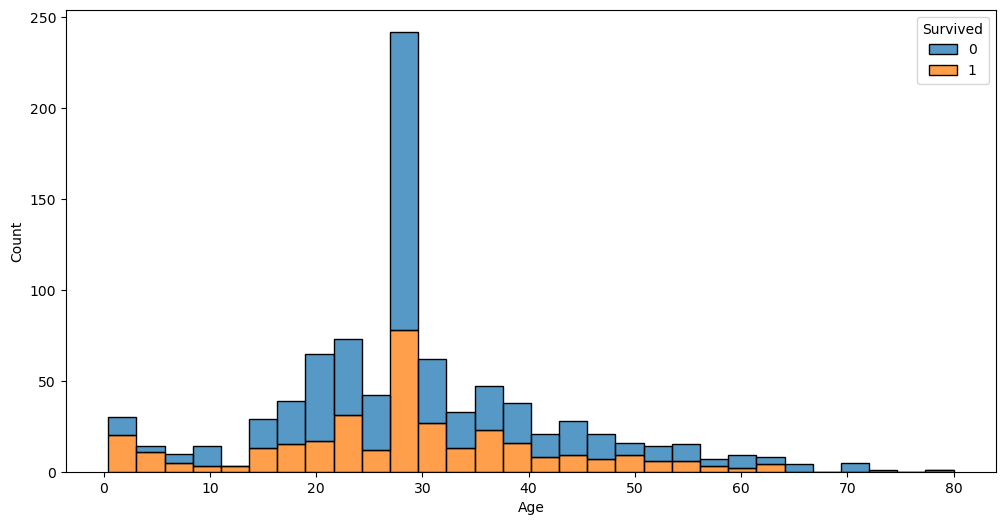

In [339]:
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack')

### Observation : The Age group of 20-40 the poeples died most less Survived, 0-10 the childrens has Survived most and died less, above 40 People died most Survived less
### What multiple='stack' means Instead of overlapping bars, it stacks orange on top of blue — so total bar height = total passengers in that age group.

<Axes: xlabel='SibSp', ylabel='Survived'>

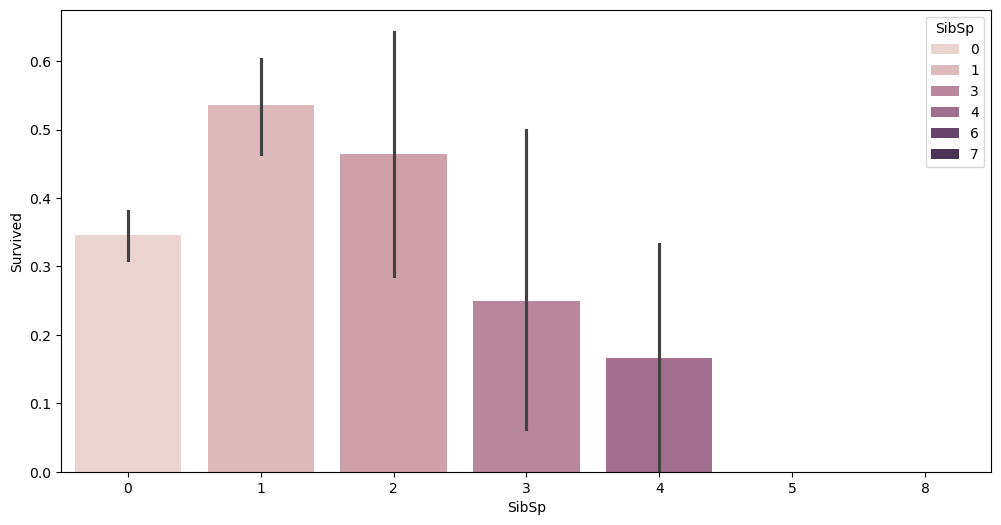

In [340]:
sns.barplot(x='SibSp',y='Survived',data=df,hue='SibSp')

### Observation : The Survival Rate of the People who had 1 Sibling or Spouse on Titanic has the Most Survival Rate

### The Confidence Interval (Black Line) Means Uncertainity = long line less Confident = Low Survival Rate

<Axes: xlabel='Parch', ylabel='Survived'>

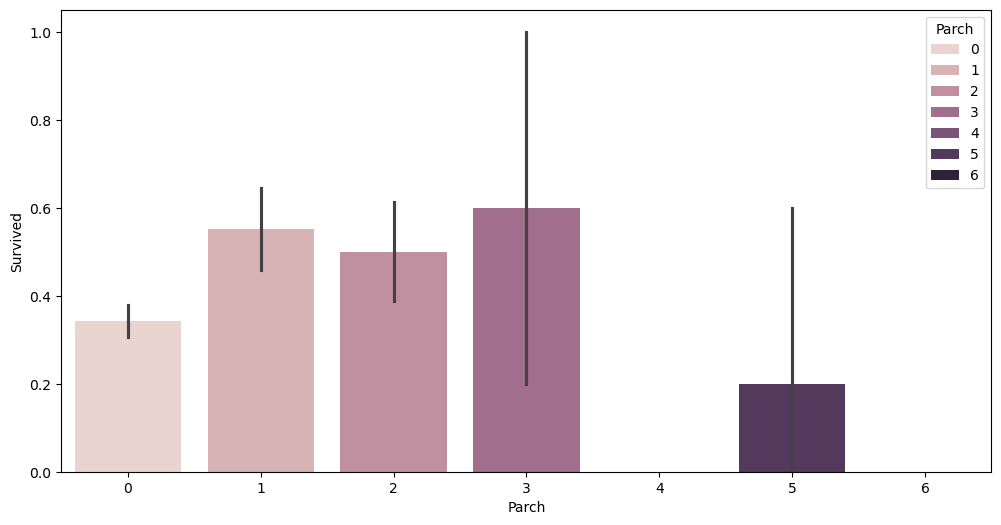

In [341]:
sns.barplot(x='Parch',y='Survived',data=df,hue='Parch')

### Observation : The Person who had 3 parent or children passenger on board has most Survival rate ~60%, but this is not riliable cuase they has 3 the reliable one is the person with 1 parch ~56%

<Axes: xlabel='Fare', ylabel='Count'>

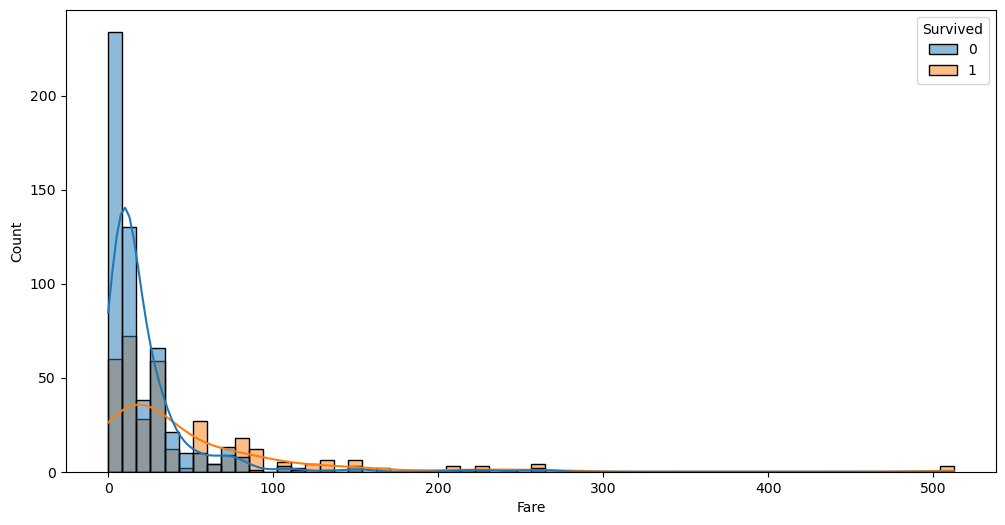

In [342]:
sns.histplot(data=df, x='Fare', hue='Survived', kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

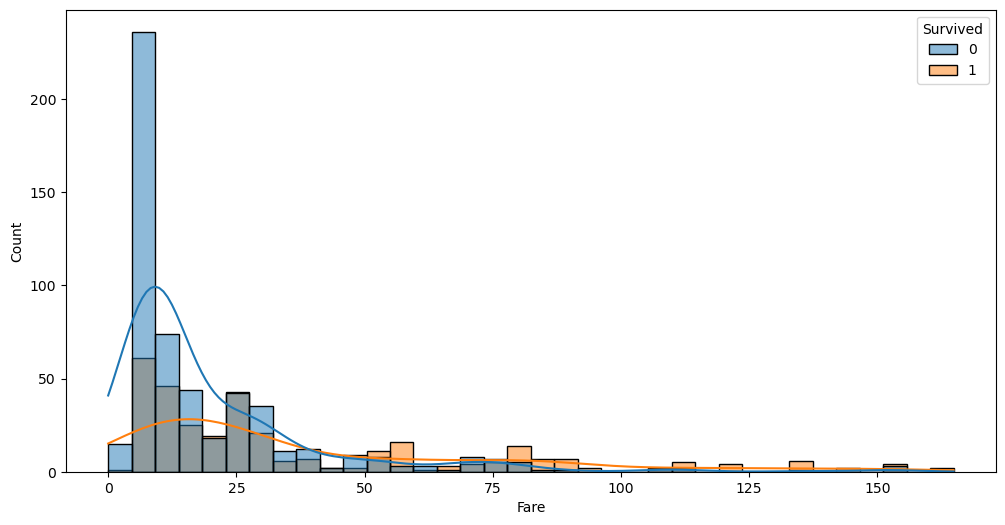

In [343]:
sns.histplot(data=df[df['Fare'] < 200], x='Fare', hue='Survived', kde=True)

### Observation : The People Paid Low Fare has low Survival Rates Died Most, Poeple Paid High Fare has HIgh Surival Rates 

C:\Users\Anurag\AppData\Local\Temp\ipykernel_18060\605891229.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked',y='Survived',data=df,palette='rainbow')


<Axes: xlabel='Embarked', ylabel='Survived'>

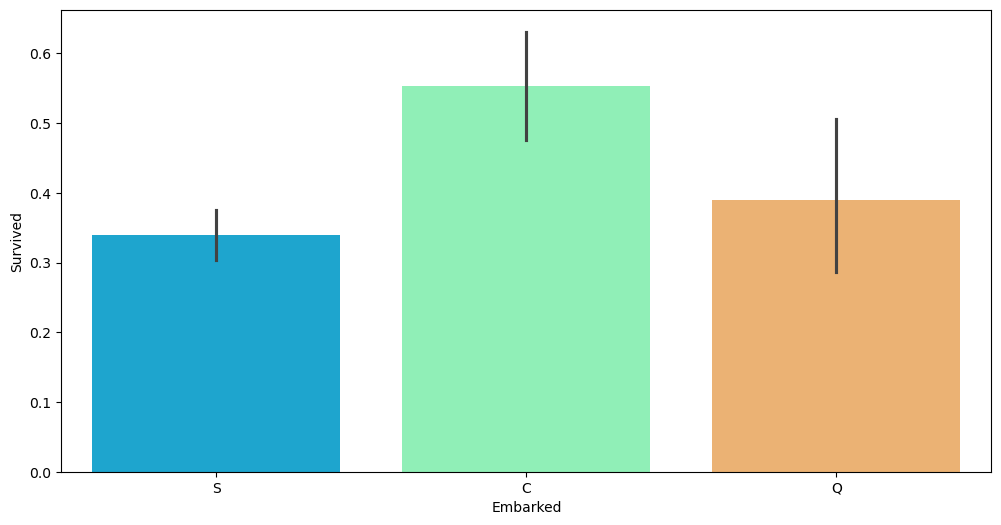

In [344]:
sns.barplot(x='Embarked',y='Survived',data=df,palette='rainbow')

### Observation : The People On Boarded Titanic from Chebourg ('C') has the most Survival Rate then Southempton (s) and Queenstown (Q)

## Handling Categorical Feature ( Feature Engg)

In [345]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [346]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [347]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [348]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [349]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [350]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Sex'].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [351]:
df['Sex'].dtype

dtype('int64')

In [352]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S


In [353]:
df['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [354]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,False,True
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,False,False


In [355]:
# Title Extraction 
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'].head()

0      Mr
1     Mrs
2    Miss
3     Mrs
4      Mr
Name: Title, dtype: object

In [356]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [357]:
# Replacing the Unique or Special title with 'Rare', Means they will be Makred as Rare
df['Title']=df['Title'].replace({'Master','Dr','Rev','Mlle','Major','Col','Countess','Capt','Ms','Sir','Lady','Mme','Don','Jonkheer'},'Rare')     
df['Title'].value_counts()

Title
Mr      517
Miss    182
Mrs     125
Rare     67
Name: count, dtype: int64

In [358]:
df['Title'] = df['Title'].map({'Mr': 0,'Miss': 1,'Mrs': 2,'Master': 3,'Rare':4})
df['Title'].head()

0    0
1    2
2    1
3    2
4    0
Name: Title, dtype: int64

In [359]:
# Here we are creating a feature called familysize to have the total family strength
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['FamilySize'].head()

0    2
1    2
2    1
3    2
4    1
Name: FamilySize, dtype: int64

In [360]:
df['FamilySize'].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [361]:
# We have Created this Feature to capture the Passenger is travelling alone or with family
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['IsAlone'].head()

0    0
1    0
2    1
3    0
4    1
Name: IsAlone, dtype: int64

<Axes: xlabel='FamilySize', ylabel='Survived'>

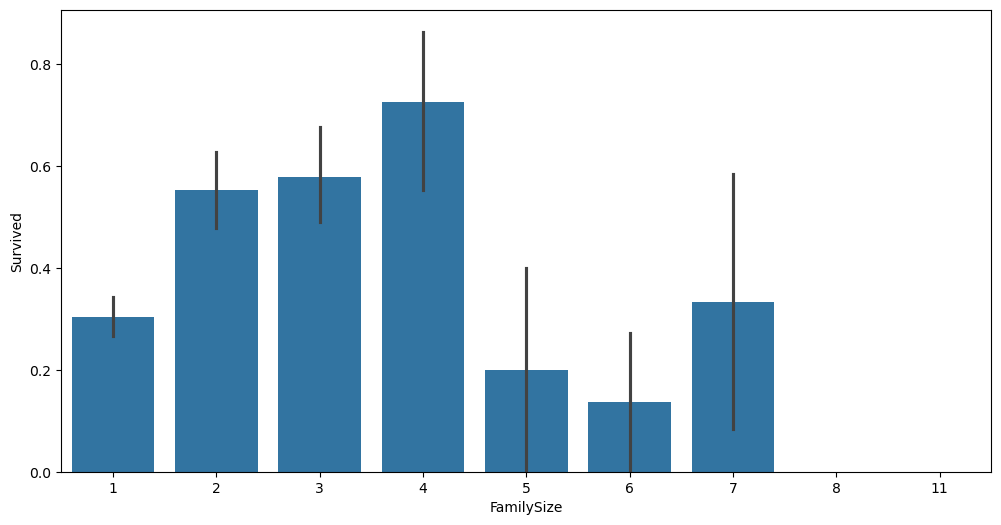

In [362]:
sns.barplot(x='FamilySize',y='Survived',data=df)

### Observation : The Family with Strenght of 4 has the realtively high Survival Chances

### Deleting the Usless text coulmns that are not used to train ML Model

In [363]:
df = df.drop('Ticket',axis=1)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,False,True,0,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,False,False,2,2,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,False,True,1,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,False,True,2,2,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,False,True,0,1,1


In [364]:
df = df.drop('Name',axis=1)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title,FamilySize,IsAlone
0,1,0,3,0,22.0,1,0,7.2500,False,True,0,2,0
1,2,1,1,1,38.0,1,0,71.2833,False,False,2,2,0
2,3,1,3,1,26.0,0,0,7.9250,False,True,1,1,1
3,4,1,1,1,35.0,1,0,53.1000,False,True,2,2,0
4,5,0,3,0,35.0,0,0,8.0500,False,True,0,1,1


In [365]:
# Feature Elimmination, the useless feature has to eliminate - Cause can affect the model performance 
df = df.drop('PassengerId',axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,False,True,0,2,0
1,1,1,1,38.0,1,0,71.2833,False,False,2,2,0
2,1,3,1,26.0,0,0,7.9250,False,True,1,1,1
3,1,1,1,35.0,1,0,53.1000,False,True,2,2,0
4,0,3,0,35.0,0,0,8.0500,False,True,0,1,1


In [366]:
# train - test split for ml model 
X=df.drop('Survived',axis=1)
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title,FamilySize,IsAlone
0,3,0,22.0,1,0,7.2500,False,True,0,2,0
1,1,1,38.0,1,0,71.2833,False,False,2,2,0
2,3,1,26.0,0,0,7.9250,False,True,1,1,1
3,1,1,35.0,1,0,53.1000,False,True,2,2,0
4,3,0,35.0,0,0,8.0500,False,True,0,1,1


### X is created for ML Model as the Information to Study 
### Y is for ML Model as the output to predict from the information

In [367]:
y=df['Survived']
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [368]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [369]:
X_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title,FamilySize,IsAlone
709,3,0,28.0,1,1,15.2458,False,False,4,3,0
439,2,0,31.0,0,0,10.5000,False,True,0,1,1
840,3,0,20.0,0,0,7.9250,False,True,0,1,1
720,2,1,6.0,0,1,33.0000,False,True,1,2,0
39,3,1,14.0,1,0,11.2417,False,False,1,2,0


In [370]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)